# Homework 6

Big Data Analytics

Greyson Newton

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
!pip install tensorflow
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import zipfile

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

### Load Data

In [84]:
# Load the Drive helper and mount
from google.colab import drive
drive.mount('/content/drive')

data_filepath = '/content/drive/MyDrive/School/hw6/hw_6_data.csv'
img_zip_filepath = '/content/drive/MyDrive/School/hw6/1000images.zip'
img_raw_dir = '/content/drive/MyDrive/School/hw6/images/raw'
img_aug_dir = '/content/drive/MyDrive/School/hw6/images/aug2'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [85]:
data = pd.read_csv(data_filepath)
data['image_number'] = data['image_number'].astype(str)

# 1. Augment the images ten mes to increase their total amount to 10,000

In [86]:
unzip_raw = False

# Unzip all images
def unzip(zip_file, destination):
    with zipfile.ZipFile(zip_file, 'r') as zf:
        zf.extractall(destination)

if unzip_raw:
  os.makedirs(img_raw_dir,exist_ok=True)
  unzip(zip_file=img_zip_filepath, destination=img_raw_dir)

  import shutil
  for f in os.listdir(os.path.join(img_raw_dir, '1000images')):
  shutil.move(
      os.path.join(img_raw_dir, '1000images', f),
      os.path.join(img_raw_dir, f),
      )

### Augment the Images

In [87]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array, array_to_img
from PIL import Image, ImageFilter  # Import ImageFilter

import numpy as np
import os

generate_images = False

# Set up the augmenter
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Create a directory to save augmented images
os.makedirs(img_aug_dir, exist_ok=True)

# Function to center crop 50%
def center_crop(img_array, crop_frac=0.5):
    h, w, _ = img_array.shape
    new_h, new_w = int(h * crop_frac), int(w * crop_frac)
    top = (h - new_h) // 2
    left = (w - new_w) // 2
    return img_array[top:top+new_h, left:left+new_w, :]

# Augment all images

if generate_images:
  for idx, row in data.iterrows():
      img_number = row['image_number']
      img_path = os.path.join(img_raw_dir, f'{img_number}.JPG')
      img = load_img(img_path)

      sharpened_img = img.filter(ImageFilter.SHARPEN)

      x = img_to_array(sharpened_img)

      # Center crop 50% first
      x = center_crop(x, crop_frac=0.75)

      # Optional: resize cropped image back to a fixed size (like 224x224) if needed
      x = array_to_img(x).resize((224, 224))  # or whatever input size your model expects
      x = img_to_array(x)

      x = x.reshape((1,) + x.shape)

      # Augment 10 times
      for i, batch in enumerate(datagen.flow(x, batch_size=1, save_to_dir=img_aug_dir, save_prefix=f"{idx}", save_format='jpeg')):
          if i >= 9:
              break

### Create New Labels for Augmented Images

In [88]:
# Create new dataframe for augmented images
augmented_filenames = os.listdir(img_aug_dir)

# Assume filename is like '0_0.jpeg', '0_1.jpeg', etc.
new_rows = []
for filename in augmented_filenames:
    orig_idx = int(filename.split('_')[0])  # recover original index
    new_rows.append({
        'image_filename': os.path.join(img_aug_dir, filename),
        'E (GPa)': data.loc[orig_idx, 'E (GPa)'],
        'Penetration_depth (nm)': data.loc[orig_idx,'Penetration_depth (nm)'],
        'Load (mN)':data.loc[orig_idx, 'Load (mN)'],

    })

augmented_data = pd.DataFrame(new_rows)

# Shuffle the data
augmented_data = augmented_data.sample(frac=1, random_state=42).reset_index(drop=True)
augmented_data

,image_filename,E (GPa),Penetration_depth (nm),Load (mN)
0,/content/drive/MyDrive/School/hw6/images/aug2/...,77.95,3917,649.854
1,/content/drive/MyDrive/School/hw6/images/aug2/...,63.10,5150,437.544
2,/content/drive/MyDrive/School/hw6/images/aug2/...,84.33,3479,499.469
3,/content/drive/MyDrive/School/hw6/images/aug2/...,58.70,3599,249.787
4,/content/drive/MyDrive/School/hw6/images/aug2/...,67.76,3597,499.845
...,...,...,...,...
13319,/content/drive/MyDrive/School/hw6/images/aug2/...,80.48,3434,499.908
13320,/content/drive/MyDrive/School/hw6/images/aug2/...,76.60,4153,649.548
13321,/content/drive/MyDrive/School/hw6/images/aug2/...,70.30,4471,699.088
13322,/content/drive/MyDrive/School/hw6/images/aug2/...,72.60,3358,449.356


### Load Images and Other Features

In [89]:
from tensorflow.keras.utils import Sequence
import random

class ImageTabularGenerator(Sequence):
    def __init__(self, df, batch_size, img_size=(224,224), shuffle=True):
        self.df = df
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.df))
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        batch_df = self.df.iloc[batch_indexes]

        # Load images
        X_img = np.zeros((self.batch_size, *self.img_size, 3))
        X_tabular = np.zeros((self.batch_size, 2))
        y = np.zeros((self.batch_size,))

        for i, (_, row) in enumerate(batch_df.iterrows()):
            img = load_img(row['image_filename'], target_size=self.img_size)
            img = img_to_array(img) / 255.0  # normalize
            X_img[i] = img
            X_tabular[i] = np.array([
                row['Penetration_depth (nm)'],
                row['Load (mN)']
            ])
            y[i] = row['E (GPa)']

        return {'input_1': X_img, 'input_2': X_tabular}, y

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indexes)

### Split the Dataset

In [90]:
# Parameters
batch_size = 32

# Scale data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
augmented_data[['Penetration_depth (nm)', 'Load (mN)']] = scaler.fit_transform(
    augmented_data[['Penetration_depth (nm)', 'Load (mN)']]
)

# Split your augmented_data into train/test
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(augmented_data, test_size=0.2, random_state=42)

# Create generators
train_generator = ImageTabularGenerator(train_df, batch_size=batch_size)
test_generator = ImageTabularGenerator(test_df, batch_size=batch_size, shuffle=False)

# 2. Use VGG16 with weights pretrained by ImageNet a er replacing its top layer.

### Update the Model Architecture

In [91]:
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.regularizers import l2

import tensorflow as tf

if tf.config.list_physical_devices('GPU'):
    print("GPU is available")
    # Set the GPU to be used by TensorFlow
    strategy = tf.distribute.OneDeviceStrategy('/device:GPU:0')
else:
    print("GPU is not available, using CPU instead")
    strategy = tf.distribute.get_strategy() # default strategy


print("REPLICAS: ", strategy.num_replicas_in_sync)



with strategy.scope():

  # Inputs
  image_input = Input(shape=(224, 224, 3), name='input_1')
  tabular_input = Input(shape=(2,), name='input_2')

  # VGG16 base
  base_model = VGG16(weights='imagenet', include_top=False, input_tensor=image_input)

  # Freeze all layers initially
  for layer in base_model.layers:
      layer.trainable = False


  # VGG output → custom dense layers
  x = Flatten()(base_model.output)
  x = Dense(1024, activation='relu')(x)
  x = Dropout(0.4)(x)  # ← higher dropout
  x = Dense(512, activation='relu')(x)
  x = Dropout(0.3)(x)

  # Tabular input processing
  y = Dense(32, activation='relu')(tabular_input)
  y = Dense(32, activation='relu')(y)

  # Combine image + tabular
  combined = Concatenate()([x, y])

  # Output
  z = Dense(64, activation='relu')(combined)
  z = Dense(1, activation='linear')(z)

  # Final model
  model = Model(inputs=[image_input, tabular_input], outputs=z)

GPU is available
REPLICAS:  1


### Train

In [92]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

with strategy.scope():


  model.compile(
      optimizer=Adam(learning_rate=1e-5),  # lower LR for fine-tuning
      loss='mse',
      metrics=['mae']  # optional: adds mean absolute error
  )


  callbacks = [
      EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True),
      ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss')
  ]

  history = model.fit(
      train_generator,
      validation_data=test_generator,
      epochs=30,
      callbacks=callbacks
  )

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - loss: 2648.8523 - mae: 44.6788

333/333 ━━━━━━━━━━━━━━━━━━━━ 91s 269ms/step - loss: 2644.3618 - mae: 44.6179 - val_loss: 66.4501 - val_mae: 6.1949
Epoch 2/30
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - loss: 96.5636 - mae: 7.7022

333/333 ━━━━━━━━━━━━━━━━━━━━ 91s 272ms/step - loss: 96.5689 - mae: 7.7023 - val_loss: 60.6555 - val_mae: 5.8463
Epoch 3/30
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - loss: 92.2515 - mae: 7.5420

333/333 ━━━━━━━━━━━━━━━━━━━━ 91s 274ms/step - loss: 92.2497 - mae: 7.5419 - val_loss: 56.3480 - val_mae: 5.5931
Epoch 4/30
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - loss: 88.6248 - mae: 7.3250

...

333/333 ━━━━━━━━━━━━━━━━━━━━ 90s 270ms/step - loss: 63.2753 - mae: 6.0594 - val_loss: 45.8763 - val_mae: 5.1201
Epoch 13/30
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - loss: 62.1498 - mae: 6.0718

333/333 ━━━━━━━━━━━━━━━━━━━━ 91s 271ms/step - loss: 62.1484 - mae: 6.0717 - val_loss: 45.7265 - val_mae: 5.1324
Epoch 14/30
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - loss: 61.6569 - mae: 6.0107

333/333 ━━━━━━━━━━━━━━━━━━━━ 90s 270ms/step - loss: 61.6543 - mae: 6.0106 - val_loss: 44.9852 - val_mae: 5.0837
Epoch 15/30
333/333 ━━━━━━━━━━━━━━━━━━━━ 84s 252ms/step - loss: 58.3849 - mae: 5.8911 - val_loss: 46.2997 - val_mae: 5.2243
Epoch 16/30
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - loss: 56.4744 - mae: 5.8090

333/333 ━━━━━━━━━━━━━━━━━━━━ 86s 257ms/step - loss: 56.4745 - mae: 5.8088 - val_loss: 44.6655 - val_mae: 5.0878
Epoch 17/30
333/333 ━━━━━━━━━━━━━━━━━━━━ 140s 252ms/step - loss: 57.1829 - mae: 5.8022 - val_loss: 45.6721 - val_mae: 5.1971
Epoch 18/30
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step - loss: 56.1751 - mae: 5.7572

333/333 ━━━━━━━━━━━━━━━━━━━━ 150s 277ms/step - loss: 56.1721 - mae: 5.7571 - val_loss: 41.7191 - val_mae: 4.8161
Epoch 19/30
333/333 ━━━━━━━━━━━━━━━━━━━━ 89s 266ms/step - loss: 52.9221 - mae: 5.6048 - val_loss: 41.9584 - val_mae: 4.8685
Epoch 20/30
333/333 ━━━━━━━━━━━━━━━━━━━━ 84s 251ms/step - loss: 53.3377 - mae: 5.6130 - val_loss: 41.9860 - val_mae: 4.8975


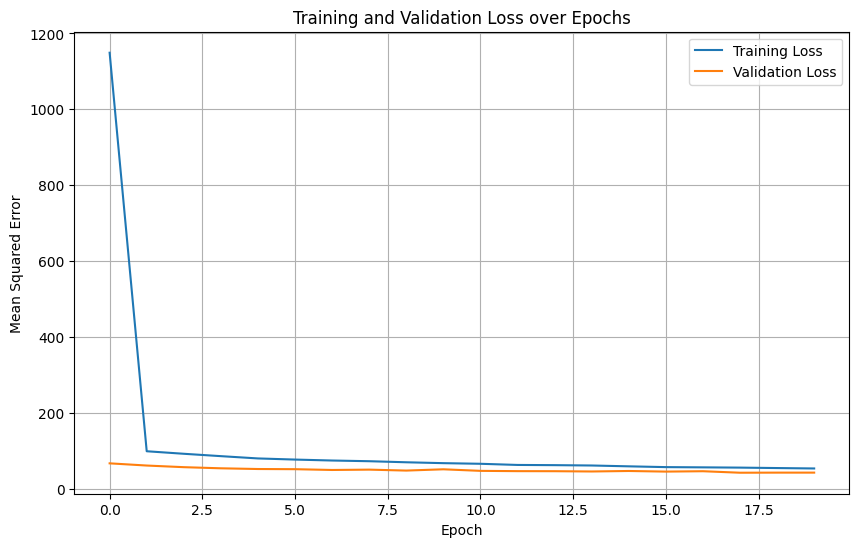

In [93]:
import matplotlib.pyplot as plt

# Plot loss
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

### Predict and Plot

In [94]:
# Predict
y_pred = model.predict(test_generator).flatten()

# Get the true labels
y_true = test_df['E (GPa)'].values[:len(y_pred)]  # adjust if needed

83/83 ━━━━━━━━━━━━━━━━━━━━ 16s 188ms/step


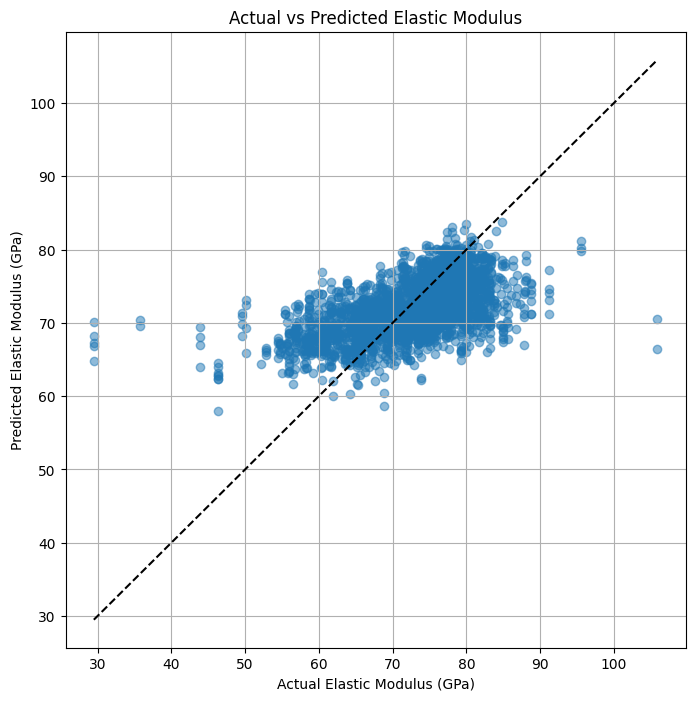

In [95]:
plt.figure(figsize=(8,8))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.xlabel('Actual Elastic Modulus (GPa)')
plt.ylabel('Predicted Elastic Modulus (GPa)')
plt.title('Actual vs Predicted Elastic Modulus')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--')  # perfect prediction line
plt.grid(True)
plt.show()

In [96]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'R² Score: {r2:.2f}')

Mean Squared Error: 41.72
R² Score: 0.31


# 3. Bonus problem (50 points). Improve performance by using addi onal fully connected layers
on top of your model and fine-tuning it.

### Fine tuning

In [97]:
# Unfreeze some of the last layers of VGG16
for layer in base_model.layers[-4:]:   # unfreeze last 4 layers
    layer.trainable = True

with strategy.scope():

  # SMALLER learning rate for fine-tuning
  model.compile(
      optimizer=Adam(learning_rate=1e-5),
      loss='mse'
  )

  history = model.fit(
      train_generator,
      validation_data=test_generator,
      epochs=20,
      callbacks = callbacks
  )

Epoch 1/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 89s 262ms/step - loss: 54.4396 - mae: 5.6149 - val_loss: 49.9406 - val_mae: 5.6522
Epoch 2/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - loss: 48.1253 - mae: 5.4113

333/333 ━━━━━━━━━━━━━━━━━━━━ 97s 291ms/step - loss: 48.1209 - mae: 5.4109 - val_loss: 33.1391 - val_mae: 4.2429
Epoch 3/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - loss: 42.7780 - mae: 5.1276

333/333 ━━━━━━━━━━━━━━━━━━━━ 94s 283ms/step - loss: 42.7760 - mae: 5.1274 - val_loss: 33.0080 - val_mae: 4.4167
Epoch 4/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 35.5074 - mae: 4.6738

333/333 ━━━━━━━━━━━━━━━━━━━━ 138s 270ms/step - loss: 35.5095 - mae: 4.6739 - val_loss: 27.2762 - val_mae: 3.9393
Epoch 5/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - loss: 33.1406 - mae: 4.5088

333/333 ━━━━━━━━━━━━━━━━━━━━ 98s 292ms/step - loss: 33.1378 - mae: 4.5087 - val_loss: 24.4149 - val_mae: 3.7185
Epoch 6/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - loss: 30.0543 - mae: 4.3178

333/333 ━━━━━━━━━━━━━━━━━━━━ 88s 263ms/step - loss: 30.0519 - mae: 4.3176 - val_loss: 22.7266 - val_mae: 3.6398
Epoch 7/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 90s 269ms/step - loss: 27.5101 - mae: 4.1473 - val_loss: 26.0010 - val_mae: 3.9892
Epoch 8/20
333/333 ━━━━━━━━━━━━━━━━━━━━ 86s 256ms/step - loss: 25.5777 - mae: 4.0200 - val_loss: 23.5689 - val_mae: 3.8298


In [98]:
# Predict
y_pred = model.predict(test_generator).flatten()

# Get the true labels
y_true = test_df['E (GPa)'].values[:len(y_pred)]  # adjust if needed

83/83 ━━━━━━━━━━━━━━━━━━━━ 17s 196ms/step


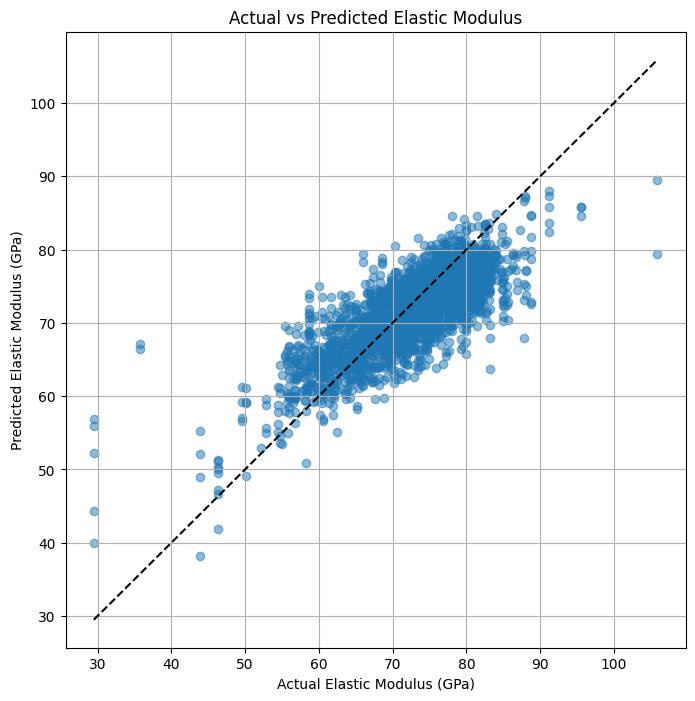

In [99]:
plt.figure(figsize=(8,8))
plt.scatter(y_true, y_pred, alpha=0.5)
plt.xlabel('Actual Elastic Modulus (GPa)')
plt.ylabel('Predicted Elastic Modulus (GPa)')
plt.title('Actual vs Predicted Elastic Modulus')
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--')  # perfect prediction line
plt.grid(True)
plt.show()

In [100]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'R² Score: {r2:.2f}')

Mean Squared Error: 22.73
R² Score: 0.63
